In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0.0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = EPFLP300()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
#idc = meta['session'] == 'session_2'
#epochs = epochs[idc]
#labels = labels[idc]
#meta = meta[idc]


Not setting metadata
137 matching events found
No baseline correction applied
Not setting metadata
130 matching events found
No baseline correction applied
Not setting metadata
137 matching events found
No baseline correction applied
Not setting metadata
150 matching events found
No baseline correction applied
Not setting metadata
150 matching events found
No baseline correction applied
Not setting metadata
150 matching events found
No baseline correction applied
Not setting metadata
125 matching events found
No baseline correction applied
Not setting metadata
142 matching events found
No baseline correction applied
Not setting metadata
130 matching events found
No baseline correction applied
Not setting metadata
142 matching events found
No baseline correction applied
Not setting metadata
137 matching events found
No baseline correction applied
Not setting metadata
142 matching events found
No baseline correction applied
Not setting metadata
137 matching events found
No baseline corre

In [3]:
epochs

Number of events,3317
Events,NonTarget: 2763Target: 554
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
epochs.metadata

In [5]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2255/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(3317, 32, 26)

In [6]:
from hoda.hoda import HODA, f_multiway
from hoda.gpu_opt import center
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import center, ledoit_wolf_shrinkage, combine_pvalues

hoda = HODA(
            rank=None,
            max_iter=64,
            tol=1e-8,
            init ='svd',
            shrinkage='lw',
            toeplitz=None,
            taper=False,
            obj='tr',
            solver='lanczos',
            keep_train_info=True,
            verbose=True,
            prune=True,
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/64 [00:00<?, ?it/s]

Fitted Tucker model of rank [1, 1] ...


HODA(keep_train_info=True, max_iter=64, obj='tr', tol=1e-08, verbose=True)

In [7]:
hoda.train_info_

,F,p,mse,update
iteration,,,,
0,0.013649,1.000000,5.297713e-11,6.937383e-02
1,0.022503,1.000000,1.728947e-10,inf
2,0.110572,1.000000,1.089707e-09,6.438891e-02
3,0.161998,1.000000,1.205259e-10,1.386937e-02
4,0.169439,1.000000,1.115325e-10,1.606498e-04
5,0.172795,1.000000,1.122935e-10,3.983285e-05
6,0.174063,1.000000,1.113209e-10,1.372255e-05
7,0.174806,1.000000,1.116953e-10,5.883910e-06
8,0.175042,1.000000,1.112803e-10,2.550379e-06


/tmp/ipykernel_2255/3216791688.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[2].set_ylim([0,None])


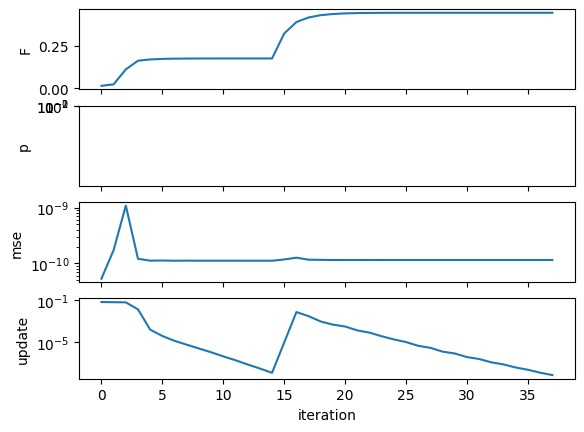

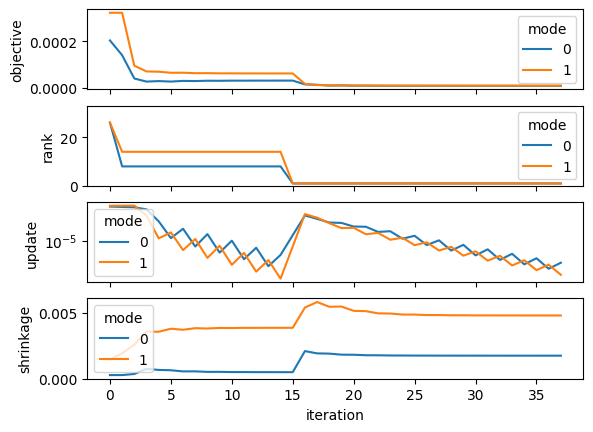

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_, x='iteration', y='F', ax=axs[0])
    axs[1].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='p', ax=axs[1])
    axs[1].set(yscale='log')
    sns.lineplot(data=hoda.train_info_, x='iteration', y='mse', ax=axs[2])
    axs[2].set(yscale="log")
    axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_, x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='rank',hue='mode', ax=axs[1])
    axs[1].set_ylim([0,max(X[0].shape)+1])
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_, x='iteration', y='shrinkage',hue='mode', ax=axs[3])


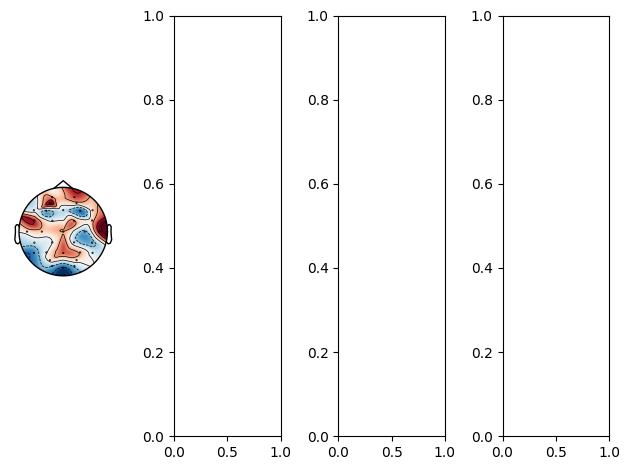

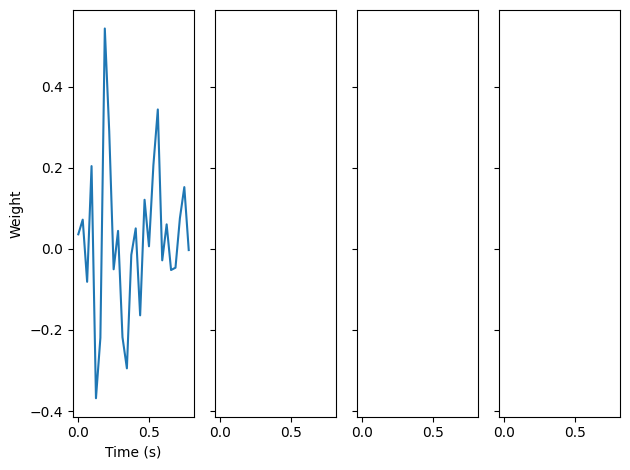

In [9]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


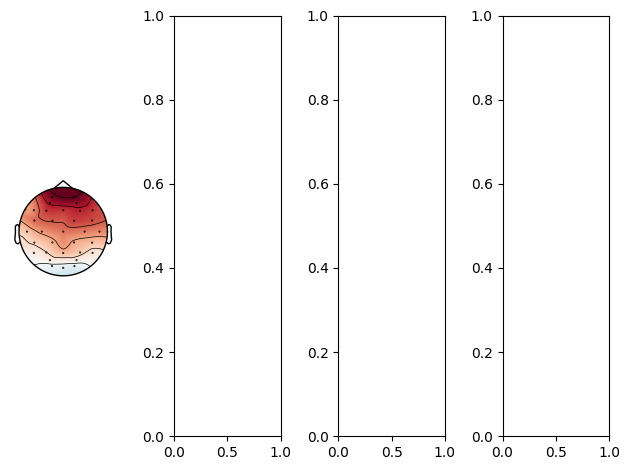

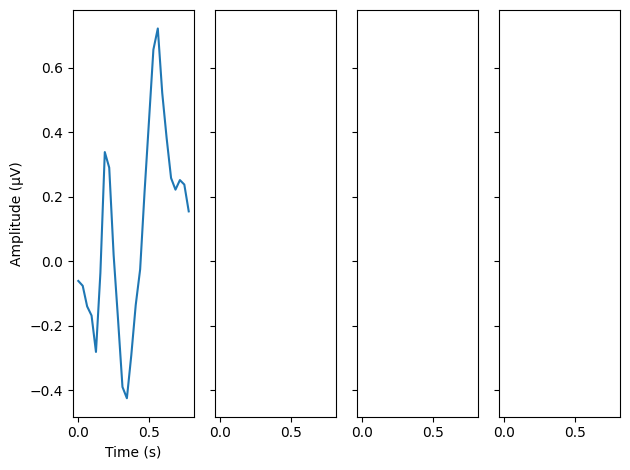

In [10]:
n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_[1] / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_[1]):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude (µV)');

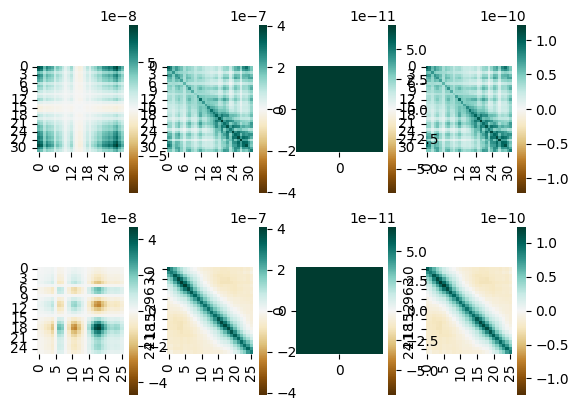

In [11]:
_, axs = plt.subplots(2,4,)
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov_w=  tl.to_numpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

In [12]:
Xt = hoda.transform(X)

In [13]:
X.shape

(3317, 32, 26)

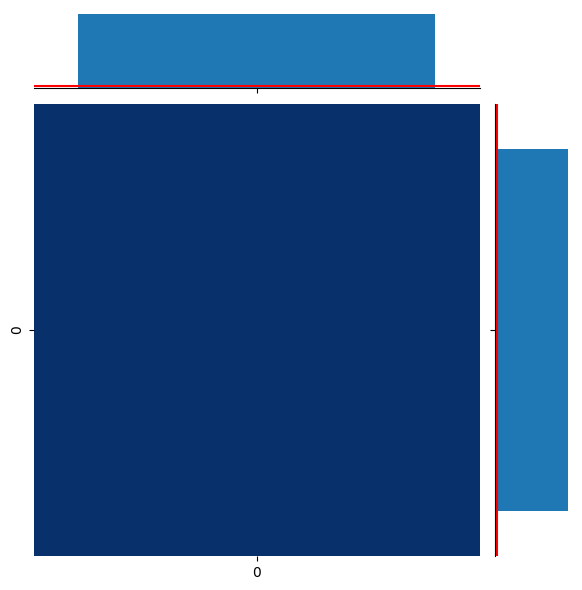

In [14]:
from hoda.hoda import f_multiway

snr,p = f_multiway(X,y)
F, p = f_oneway(Xt,y)
F = tl.to_numpy(F)
p = tl.to_numpy(p)

F_sp = []
for r in range(Xt.shape[1]):
    F_sp.append(f_multiway(Xt[:,r,:],y)[0])

    
F_tmp = []
for r in range(Xt.shape[2]):
    F_tmp.append(f_multiway(Xt[:,:,r],y)[0])  

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)
g.ax_marg_x.axhline(snr, color='red')
g.ax_marg_y.axvline(snr, color='red')


In [15]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

X_viz = X.reshape((X.shape[0],-1))
Xt_viz = Xt.reshape((Xt.shape[0],-1))
n_components = 2
decomp  = PCA(n_components=n_components, whiten=True)
X_viz = decomp.fit_transform(tl.to_numpy(X_viz))
Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_viz))

cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
c = np.vectorize(cmap.get)(y)    
fig, axs = plt.subplots(1,2, figsize=(12,6), sharex=True, sharey=True)
axs[0].scatter(X_viz[:,0], X_viz[:,1], c=c)
axs[0].set_aspect('equal')
axs[1].scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
axs[1].set_aspect('equal')

ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

No projector specified for this dataset. Please consider the method self.add_proj.


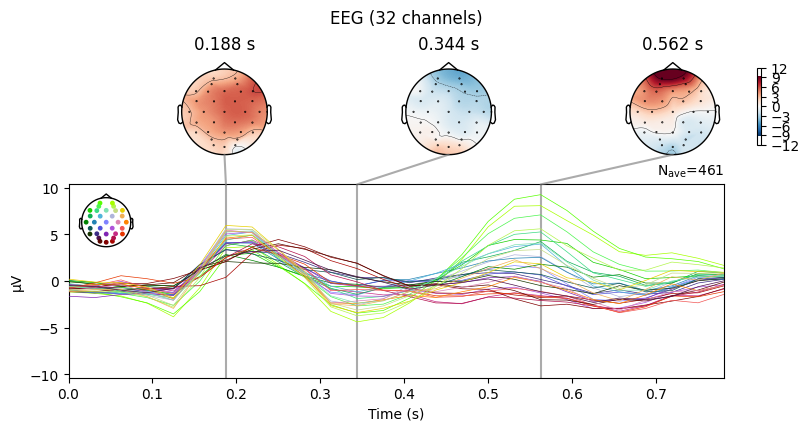

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2255/995508154.py:21: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


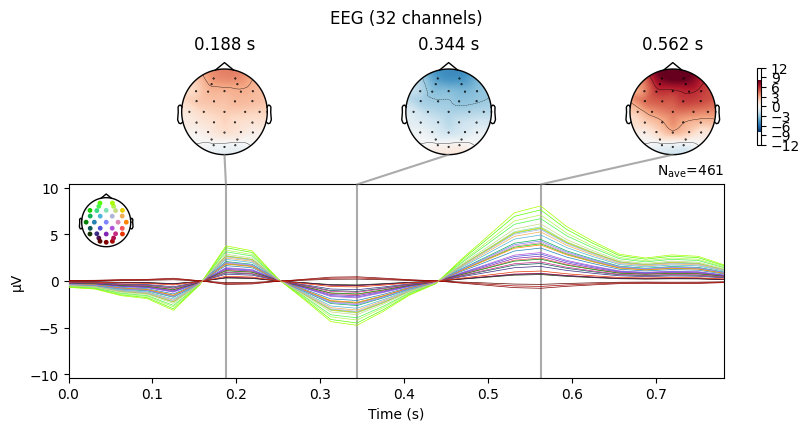

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2255/995508154.py:29: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_defl._data -= epochs_rec.get_data()


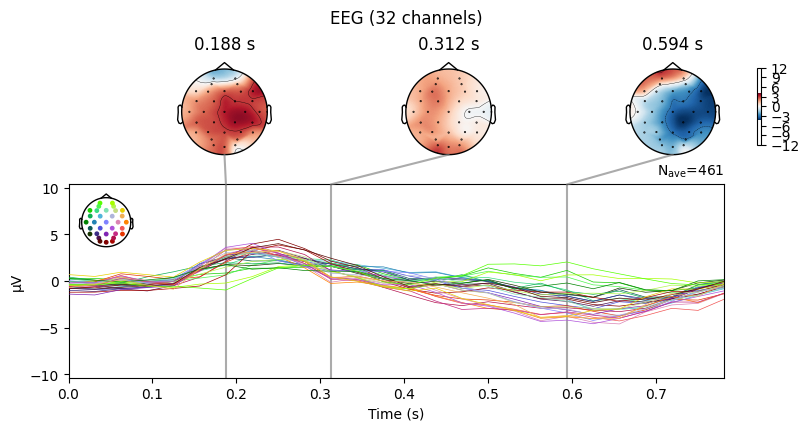

In [16]:
from mne import combine_evoked

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
vmax = np.max(np.abs(target.data))
vmax = max(vmax, np.max(np.abs(non_target.data)))
vmax *=1.1e6

joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-vmax,vmax]),
        unit=True,
    )
)


contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast_rec = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_rec.plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast_defl = combine_evoked([target, non_target], weights=[1,-1])
_= contrast_defl.plot_joint(**joint_args)

## Classification

0.8144341615807649


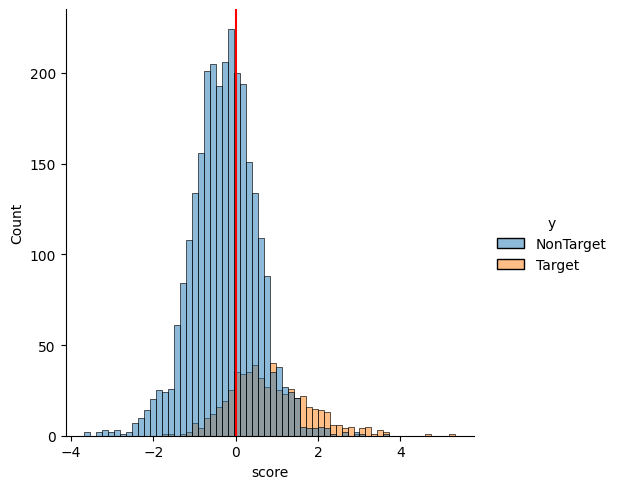

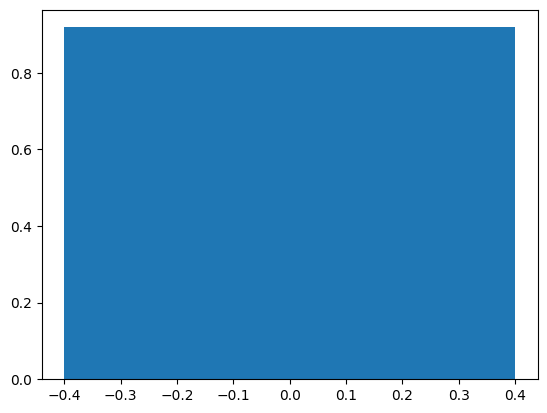

In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis 
from sklearn.metrics import roc_auc_score
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0],-1)))
Xt_flat = StandardScaler().fit_transform(Xt_flat)
clf = LogisticRegressionCV(Cs=10, penalty='l1', solver='liblinear', class_weight='balanced', scoring='roc_auc')
clf.fit(Xt_flat, y)
score_pred = clf.decision_function(Xt_flat)

df = pd.DataFrame(dict(score=score_pred,y=y))
g = sns.displot(df, x='score', hue='y')
plt.axvline(0, color='red')
print(roc_auc_score(y,score_pred))

fig, ax = plt.subplots(1,1)
_ = ax.bar(np.arange(Xt_flat.shape[1]), np.abs(clf.coef_.squeeze()))
